In [16]:
import numpy as np
# import RockSat_json
# import RockSat_1_14_fitting_functions as R_fitting
import json
import scipy.constants as c
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rcParams['font.size'] = 20
mpl.rcParams['axes.labelsize'] = 30
mpl.rcParams['legend.fontsize'] = 25
mpl.rcParams['lines.linewidth'] = 5
mpl.rcParams['lines.markersize'] = 8
mpl.rcParams['grid.linewidth'] = 3


figs = 'Fig/'

In [17]:
day = pd.read_csv('Data/day_lat.txt', sep='\s+', skiprows=34)
night = pd.read_csv('Data/night_lat.txt', sep='\s+', skiprows=32)
print(day.keys())
print(night.keys())

Index(['GEOD', 'Ne/cm-3', 'Ne/NmF2', 'Tn/K', 'Ti/K', 'Te/K', 'O+', 'N+', 'H+',
       'He+', 'O2+', 'NO+', 'Clust', 'TEC', 't/%'],
      dtype='object')
Index(['GEOD', 'Ne/cm-3', 'Ne/NmF2', 'Tn/K', 'Ti/K', 'Te/K', 'O+', 'N+', 'H+',
       'He+', 'O2+', 'NO+', 'Clust', 'TEC', 't/%'],
      dtype='object')


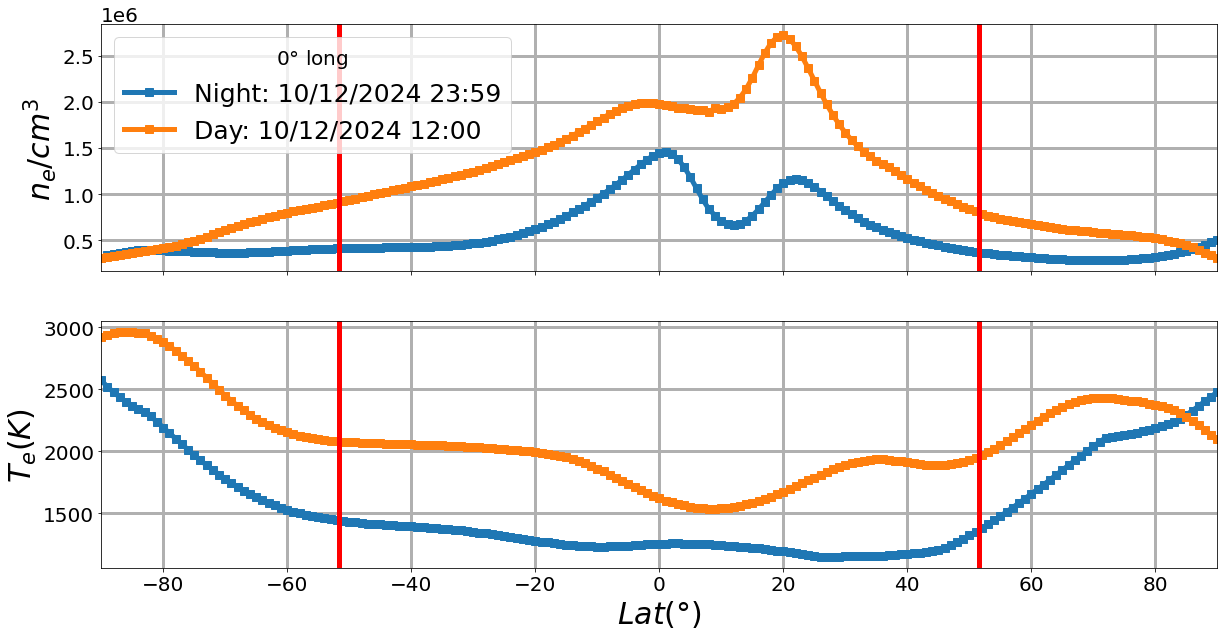

In [18]:
fig, ax = plt.subplots(2, 1, figsize = (20, 10), sharex = True)


ax[0].plot(night['GEOD'], night['Ne/cm-3'], marker = 's', label = 'Night: 10/12/2024 23:59')
ax[0].plot(day['GEOD'], day['Ne/cm-3'], marker = 's', label = 'Day: 10/12/2024 12:00')


ax[1].plot(night['GEOD'], night['Te/K'], marker = 's', label = 'Night: 10/12/2024 23:59')
ax[1].plot(day['GEOD'], day['Te/K'], marker = 's', label = 'Day: 10/12/2024 12:00')

ax[0].axvline(51.6, linewidth = 5, c = 'r')
ax[0].axvline(-51.6, linewidth = 5, c = 'r')

ax[1].axvline(51.6, linewidth = 5, c = 'r')
ax[1].axvline(-51.6, linewidth = 5, c = 'r')


ax[0].set_xlim(-90,90)
ax[0].legend(title = r'$0 \degree$ long')
ax[0].grid()
ax[1].grid()

ax[0].set_ylabel(r'$n_e/cm^3$')
ax[1].set_ylabel(r'$T_e (K)$')

ax[1].set_xlabel(r'$Lat (\degree)$')


fig.savefig(figs + 'TOD_lat.png', dpi = 400)

In [19]:
print(c.unit('Boltzmann constant'))
print(c.unit('electric constant'))

J K^-1
F m^-1


In [20]:
day['Ne/cm-3'] * 10**6

0      310752000000
1      318832000000
2      327817000000
3      337453000000
4      347518000000
           ...     
176    431192000000
177    395658000000
178    362873000000
179    334989000000
180    310886000000
Name: Ne/cm-3, Length: 181, dtype: int64

In [21]:
lD_day = np.sqrt(c.k * c.epsilon_0 * night['Te/K'][45]/(c.elementary_charge**2 * night['Ne/cm-3'][45] * 10**6))*100
print(lD_day)

0.3994896021862596


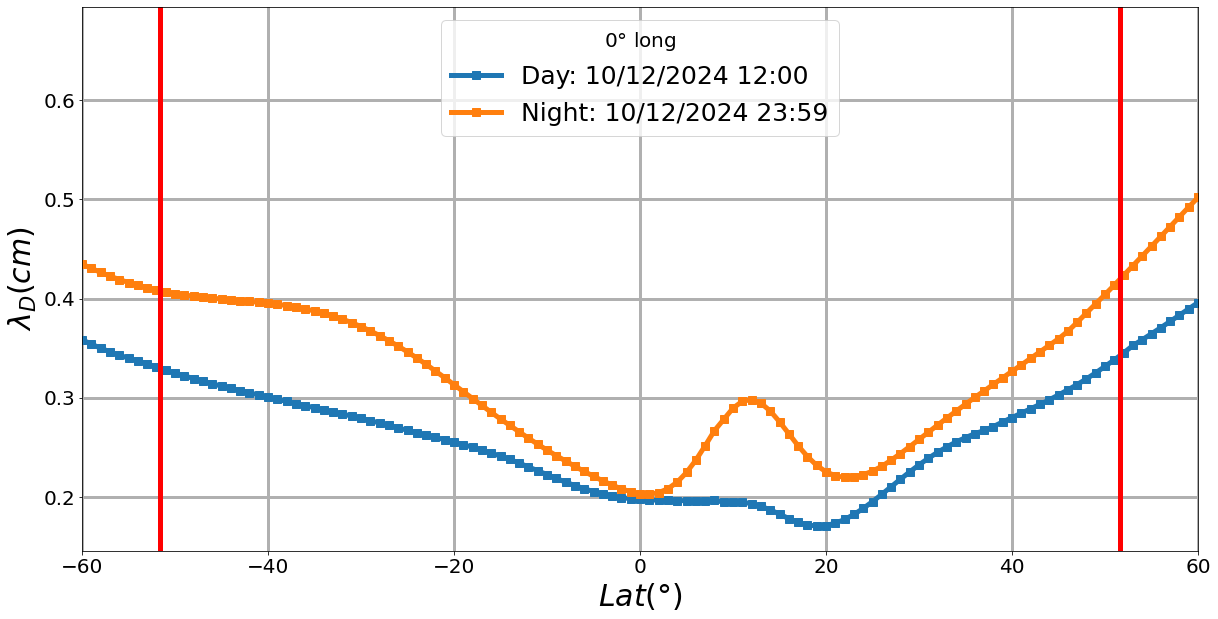

In [22]:
fig, ax = plt.subplots(1, 1, figsize = (20, 10), sharex = True)

lD_day = np.sqrt(c.k * c.epsilon_0 * day['Te/K']/(c.elementary_charge**2 * day['Ne/cm-3'] * 10**6))*100
lD_night = np.sqrt(c.k * c.epsilon_0 * night['Te/K']/(c.elementary_charge**2 * night['Ne/cm-3'] * 10**6)) * 100


ax.plot(day['GEOD'], lD_day, marker = 's', label = 'Day: 10/12/2024 12:00')
ax.plot(night['GEOD'], lD_night, marker = 's', label = 'Night: 10/12/2024 23:59')


ax.axvline(51.6, linewidth = 5, c = 'r')
ax.axvline(-51.6, linewidth = 5, c = 'r')

ax.set_xlim(-60,60)
ax.legend(title = r'$0 \degree$ long')
ax.grid()
ax.set_xlabel(r'$Lat (\degree)$')
ax.set_ylabel(r'$\lambda_D (cm)$')


fig.savefig(figs + 'lambdaD_lat.png', dpi = 200)

In [23]:
lD_day = np.sqrt(c.k * c.epsilon_0 * 1200/(c.elementary_charge**2 * 5500 * 10**6))* 100
print(lD_day)

3.2234051157039234
